## 1 Imports and Helper Functions

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import loadmat  # For loading .mat files
from scipy.stats import kurtosis

# Set plotting style
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

# Data directory
DATA_DIR = "data"

In [2]:
def list_sample_files():
    """
    List all .mat sample files in the data directory.
    
    Returns:
    --------
    files : list of str
        Sorted list of .mat sample filenames
    """
    return sorted([f for f in os.listdir(DATA_DIR) if f.endswith("_sample.mat")])


def load_sample(file_name):
    """
    Load a sample .mat file.
    
    Parameters:
    -----------
    file_name : str
        Name of the .mat file (e.g., 'H_353rpm_sample.mat')
    
    Returns:
    --------
    data : dict
        Contains keys: time_acc, acc_m_s2, acc_g, fs_acc, time_rpm, rpm, 
                      fs_rpm, mean_rpm, condition, rpm_nominal
    """
    path = os.path.join(DATA_DIR, file_name)
    
    # Load MATLAB format
    mat_data = loadmat(path)
    
    # Extract data (loadmat adds metadata keys starting with '__')
    data = {k: v for k, v in mat_data.items() if not k.startswith('__')}
    
    # Flatten scalar values for easier use
    for key in ['fs_acc', 'fs_rpm', 'mean_rpm', 'rpm_nominal']:
        if key in data and hasattr(data[key], 'flatten'):
            data[key] = float(data[key].flatten()[0])
    
    # Flatten time and signal arrays (remove extra dimensions)
    for key in ['time_acc', 'acc_m_s2', 'acc_g', 'time_rpm', 'rpm']:
        if key in data and hasattr(data[key], 'flatten'):
            data[key] = data[key].flatten()
    
    # Convert condition to string
    if 'condition' in data:
        if hasattr(data['condition'], '__iter__') and not isinstance(data['condition'], str):
            data['condition'] = str(data['condition'][0]) if len(data['condition']) > 0 else ''
        else:
            data['condition'] = str(data['condition'])
    
    return data

In [3]:
def compute_spectrum(signal_data, fs, window=True):
    """
    Compute single-sided amplitude spectrum.
    
    Parameters:
    -----------
    signal_data : ndarray
        Time-domain signal
    fs : float
        Sampling frequency in Hz
    window : bool
        If True, apply Hanning window before FFT (default: True)
    
    Returns:
    --------
    freq : ndarray
        Frequency vector (positive frequencies only)
    amplitude : ndarray
        Single-sided amplitude spectrum
    """
    N = len(signal_data)
    
    # Apply window to reduce spectral leakage
    if window:
        win = np.hanning(N)
        signal_windowed = signal_data * win
        # Compensate for window amplitude loss
        window_correction = 2.0 / np.sum(win)  # = 2/(N*mean(win)), standard single-sided amplitude correction
    else:
        signal_windowed = signal_data
        window_correction = 2.0 / N
    
    # Compute FFT
    fft_vals = np.fft.fft(signal_windowed)
    
    # Single-sided spectrum (positive frequencies only)
    # Don't double DC component (index 0) and Nyquist (if N is even)
    freq = np.fft.fftfreq(N, 1/fs)[:N//2]
    amplitude = np.abs(fft_vals[:N//2]) * window_correction
    amplitude[0] /= 2  # DC component should not be doubled
    if N % 2 == 0:
        amplitude[-1] /= 2  # Nyquist component should not be doubled (if N is even)
    
    return freq, amplitude


def simple_time_features(signal_data):
    """
    Compute simple time-domain features.
    
    Parameters:
    -----------
    signal_data : ndarray
        Time-domain signal
    
    Returns:
    --------
    features : dict
        Dictionary containing RMS, peak, and kurtosis
    """
    rms = np.sqrt(np.mean(signal_data**2))
    peak = np.max(np.abs(signal_data))
    # Use fisher=False for kurtosis (Normal distribution = 3)
    kurt = kurtosis(signal_data, fisher=False)
    
    return {
        'RMS': rms,
        'Peak': peak,
        'Kurtosis': kurt
    }


def envelope_spectrum(signal_data, fs, bandpass=None):
    """
    Compute envelope spectrum using Hilbert transform.
    
    Parameters:
    -----------
    signal_data : ndarray
        Time-domain signal
    fs : float
        Sampling frequency in Hz
    bandpass : tuple or None
        If tuple (low_freq, high_freq), apply band-pass filter before envelope.
        If None, no filtering is applied.
    
    Returns:
    --------
    freq : ndarray
        Frequency vector for envelope spectrum
    env_spectrum : ndarray
        Envelope spectrum amplitude
    envelope : ndarray
        Envelope time series
    filtered_signal : ndarray
        Band-pass filtered signal (or original if bandpass=None)
    """
    # Apply band-pass filter if requested
    if bandpass is not None:
        low_freq, high_freq = bandpass
        sos = signal.butter(4, [low_freq, high_freq], btype='bandpass', fs=fs, output='sos')
        filtered_signal = signal.sosfilt(sos, signal_data)
    else:
        filtered_signal = signal_data
    
    # Compute analytic signal using Hilbert transform
    analytic_signal = signal.hilbert(filtered_signal)
    
    # Envelope is the magnitude of the analytic signal
    envelope = np.abs(analytic_signal)
    
    # Compute spectrum of the envelope
    f_seq, env_spectrum = compute_spectrum(envelope, fs)
    
    return f_seq, env_spectrum, envelope, filtered_signal

In [4]:
# Bearing Geometry and Fault Characteristic Frequencies
# These values are specific to the bearing type used in the experiment

# Bearing fault characteristic frequencies (orders relative to shaft speed)
# These are cycles per revolution - multiply by shaft frequency (Hz) to get fault frequency

BPFI = 10.824  # Ball Pass Frequency Inner race (cycles per revolution)
BPFO = 8.176   # Ball Pass Frequency Outer race (cycles per revolution)
BSF = 3.464    # Ball Spin Frequency (cycles per revolution)
FTF = 0.414    # Fundamental Train Frequency (cage rotation, cycles per revolution)

# Physical Interpretation:
# 
# BPFI: How many times per shaft revolution do rolling elements pass over a point on the INNER race
#       Higher than BPFO because inner race rotates with shaft (relative motion is faster)
#
# BPFO: How many times per shaft revolution do rolling elements pass over a point on the OUTER race  
#       Lower than BPFI because outer race is stationary
#
# BSF: How fast each rolling element (ball) rotates on its own axis
#      Fault on a ball creates 2 impacts per rotation → actual fault freq = 2×BSF
#
# FTF: How fast the cage (which holds the rolling elements) rotates
#      Rarely used for fault diagnosis but important for understanding bearing kinematics

def calculate_fault_frequency(rpm, fault_order):
    """
    Calculate fault frequency in Hz from RPM and fault order.
    
    Parameters:
    -----------
    rpm : float
        Shaft rotational speed in RPM (use measured mean RPM for accuracy)
    fault_order : float
        Fault characteristic order (BPFI, BPFO, BSF, or FTF)
    
    Returns:
    --------
    freq_hz : float
        Fault frequency in Hz
    
    Theory:
    -------
    Fault frequency = (Fault Order) × (Shaft Frequency)
    where Shaft Frequency [Hz] = RPM / 60
    
    Example:
    At mean RPM ≈ 855 (nominal 353), shaft frequency = 855/60 = 14.25 Hz
    BPFI fault frequency = 10.824 × 14.25 = 154.2 Hz
    """
    shaft_freq_hz = rpm / 60.0
    fault_freq_hz = fault_order * shaft_freq_hz
    return fault_freq_hz


def add_rpm_harmonics(ax, rpm, max_freq=2000, n_harmonics=1, color='gray', alpha=0.3, label_prefix=''):
    """
    Add vertical line for shaft speed (1×RPM) to a spectrum plot.
    
    This marks the fundamental rotational frequency, which is useful as a reference
    but should NOT be confused with bearing fault frequencies (which are much higher).
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to plot on
    rpm : float
        Rotational speed in RPM (use measured mean RPM for accuracy)
    max_freq : float
        Maximum frequency to plot harmonics up to
    n_harmonics : int
        Number of harmonics to show (default 3: shows 1×, 2×, 3×RPM)
    color : str
        Color of the harmonic line
    alpha : float
        Transparency of the line
    label_prefix : str
        Prefix for labels (e.g., 'H: ' for healthy)
    """
    freq_hz = rpm / 60.0  # Convert RPM to Hz (shaft frequency)
    
    # Show only the fundamental (1×RPM) as a clear reference
    if freq_hz <= max_freq:
        ax.axvline(freq_hz, color=color, linestyle='--', linewidth=1.0, alpha=alpha+0.2)
        ax.text(freq_hz, ax.get_ylim()[1] * 0.95, f'{label_prefix}1×RPM\n({freq_hz:.1f} Hz)', 
               rotation=90, va='top', ha='right', fontsize=8, alpha=0.7)


def add_bearing_fault_frequencies(ax, rpm, fault_type, max_freq=2000, color='red', alpha=0.5, n_harmonics=3):
    """
    Add vertical lines for bearing fault characteristic frequencies.
    
    Bearing faults create periodic impacts that appear as distinct peaks in the envelope spectrum.
    This function marks the expected frequencies based on bearing geometry and rotational speed.
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to plot on
    rpm : float
        Rotational speed in RPM (use measured mean RPM for accuracy)
    fault_type : str
        Type of fault: 'IR' (inner race), 'OR' (outer race), or 'Roller'
    max_freq : float
        Maximum frequency to plot up to
    color : str
        Color of the fault frequency lines
    alpha : float
        Transparency of the lines
    n_harmonics : int
        Number of harmonics to show (default 3: fundamental + 2 harmonics)
    
    Theory:
    -------
    Each fault type has a characteristic frequency based on bearing geometry:
    
    Inner Race (IR): fault_freq = BPFI × (RPM/60)
        - Inner race rotates with shaft
        - Rolling elements pass over fault more frequently
        - Typically 8-12 times per revolution for common bearings
    
    Outer Race (OR): fault_freq = BPFO × (RPM/60)  
        - Outer race is stationary
        - Lower frequency than inner race
        - Typically 6-10 times per revolution
    
    Roller/Ball: fault_freq = 2×BSF × (RPM/60)
        - Factor of 2 because defect hits twice per ball rotation
        - Typically 4-7 times per revolution
        - Lowest of the three fault frequencies
    """
    freq_hz = rpm / 60.0  # Shaft frequency in Hz
    
    if fault_type == 'IR':
        # Inner race fault: BPFI × shaft speed (Hz)
        fault_order = BPFI
        label = 'BPFI'
    elif fault_type == 'OR':
        # Outer race fault: BPFO × shaft speed (Hz)
        fault_order = BPFO
        label = 'BPFO'
    elif fault_type == 'Roller':
        # Rolling element fault: 2×BSF × shaft speed (Hz)
        # (factor of 2 because each defect hits twice per revolution)
        fault_order = 2 * BSF
        label = '2×BSF'
    else:
        return
    
    fault_freq = fault_order * freq_hz  # Actual fault frequency in Hz
    
    # Plot fundamental and up to n_harmonics
    for i in range(1, n_harmonics + 1):
        f = i * fault_freq
        if f <= max_freq:
            ax.axvline(f, color=color, linestyle=':', linewidth=1.2, alpha=alpha)
            if i == 1:
                ax.text(f, ax.get_ylim()[1] * 0.88, f'{label}\n({f:.1f} Hz)', 
                       rotation=90, va='top', ha='right', fontsize=8, color=color, weight='bold')
            else:
                ax.text(f, ax.get_ylim()[1] * 0.88, f'{i}×{label}', 
                       rotation=90, va='top', ha='right', fontsize=7, color=color, alpha=0.7)

---

## 2 Data and Experimental Setup

In [5]:
# List all sample files
sample_files = list_sample_files()

print(f"Found {len(sample_files)} sample files:")
print()

# Parse and display in a table
file_info = []
for fname in sample_files:
    data = load_sample(fname)
    n_samples = len(data['time_acc'])
    fs = float(data['fs_acc'])
    duration_corrected = (n_samples) / fs  # Correct duration
    
    file_info.append({
        'File': fname,
        'Condition': str(data['condition']),
        'Nominal RPM': int(data['rpm_nominal']),
        'Mean RPM': float(data['mean_rpm']),
        'Sampling Freq (Hz)': fs,
        'Duration (s)': duration_corrected
    })

df_files = pd.DataFrame(file_info)
df_files

Found 8 sample files:



,File,Condition,Nominal RPM,Mean RPM,Sampling Freq (Hz),Duration (s)
0,H_353rpm_sample.mat,H,353,338.789890,20480.0,2.0
1,H_877rpm_sample.mat,H,877,858.488691,20480.0,2.0
2,IR_353rpm_sample.mat,IR,353,335.769964,20480.0,2.0
3,IR_877rpm_sample.mat,IR,877,854.887580,20480.0,2.0
4,OR_353rpm_sample.mat,OR,353,340.073907,20480.0,2.0
5,OR_877rpm_sample.mat,OR,877,858.940172,20480.0,2.0
6,Roller_353rpm_sample.mat,Roller,353,338.803865,20480.0,2.0
7,Roller_877rpm_sample.mat,Roller,877,858.124634,20480.0,2.0


### Experimental Setup

The data were acquired from a custom bearing test rig designed for controlled fault injection studies. The test rig features:

- **Radial and axial load control** for realistic operating conditions
- **Variable speed motor** for testing at different rotational speeds
- **High-frequency accelerometers** (20.48 kHz sampling) for vibration measurement
- **Precisely manufactured faults** on bearing components (inner race, outer race, rolling elements)

<div align="center">

| Test Rig Overview | Internal Configuration | Applied Loads |
|:-----------------:|:----------------------:|:-------------:|
| <img src="images/TestRig.jpg" width="250"/> | <img src="images/TestRigInside_cut.png" width="250"/> | <img src="images/TestRigLoads_.jpg" width="250"/> |

**Figure:** (Left) Complete test rig assembly. (Center) Internal view showing bearing housing and load application mechanism. (Right) Schematic of radial and axial load configuration.

</div>

<div align="center">
<img src="images/bearing_lateral.JPEG" width="400"/>

**Figure:** Lateral view of the test bearing showing the measurement location and load direction.
</div>

<div align="center">
<img src="images/damages.png" width="500"/>

**Figure:** Manufactured bearing faults used in the experiments. The inner race (IR) and outer race (OR) faults are precisely milled slots with dimensions **2 mm × 0.5 mm** (diameter × depth), creating controlled localized defects that simulate real-world bearing damage. Source: [Giraudo et al., 2025](https://www.mdpi.com/1424-8220/25/8/2419)
</div>

**Test Conditions:**
- Radial load: 124.8 kN
- Axial load: 0 kN
- Operating speeds: 353 rpm and 877 rpm
- Bearing type: Spherical roller bearing (reference geometry in Section 5)

---


## 3 Load Example Pair: Healthy vs Inner Race Fault

Let's compare a **healthy bearing** with an **inner race fault** at **877 rpm**.

In [6]:
# Load healthy sample at 877 rpm
data_h = load_sample('H_877rpm_sample.mat')

# Load inner race fault at 877 rpm
data_ir = load_sample('IR_877rpm_sample.mat')

# Load roller fault at 877 rpm
data_re = load_sample('Roller_877rpm_sample.mat')

# Load outer race fault at 877 rpm
data_or = load_sample('OR_877rpm_sample.mat')

print("Healthy bearing (877 rpm):")
print(f"  Condition: {data_h['condition']}")
print(f"  Sampling frequency: {data_h['fs_acc']:.1f} Hz")
print(f"  Mean RPM: {data_h['mean_rpm']:.1f}")
print(f"  Duration: {data_h['time_acc'][-1]:.2f} s")
print(f"  Number of samples: {len(data_h['acc_m_s2'])}")
print()

print("Inner race fault (877 rpm):")
print(f"  Condition: {data_ir['condition']}")
print(f"  Sampling frequency: {data_ir['fs_acc']:.1f} Hz")
print(f"  Mean RPM: {data_ir['mean_rpm']:.1f}")
print(f"  Duration: {data_ir['time_acc'][-1]:.2f} s")
print(f"  Number of samples: {len(data_ir['acc_m_s2'])}")

Healthy bearing (877 rpm):
  Condition: H
  Sampling frequency: 20480.0 Hz
  Mean RPM: 858.5
  Duration: 2.00 s
  Number of samples: 40960

Inner race fault (877 rpm):
  Condition: IR
  Sampling frequency: 20480.0 Hz
  Mean RPM: 854.9
  Duration: 2.00 s
  Number of samples: 40960


---

## 4 Time-Domain Visualization and Kurtosis

### What is Kurtosis?

### $\frac{E((x-\overline{x})^4)}{STD^4(x)}$


**Kurtosis** is a statistical measure of the "tailedness" of a probability distribution. In vibration analysis:

- **Low kurtosis** (≈ 3 for Gaussian noise): Smooth, random vibration
- **High kurtosis** (>> 3): Signal with sharp, impulsive events (typical of bearing faults)

When a bearing has a localized fault (crack, spall), the rolling elements hit the damaged area, creating periodic **impulses**. These impulses increase the kurtosis of the vibration signal.

Let's visualize the acceleration signals and compute their time-domain features.

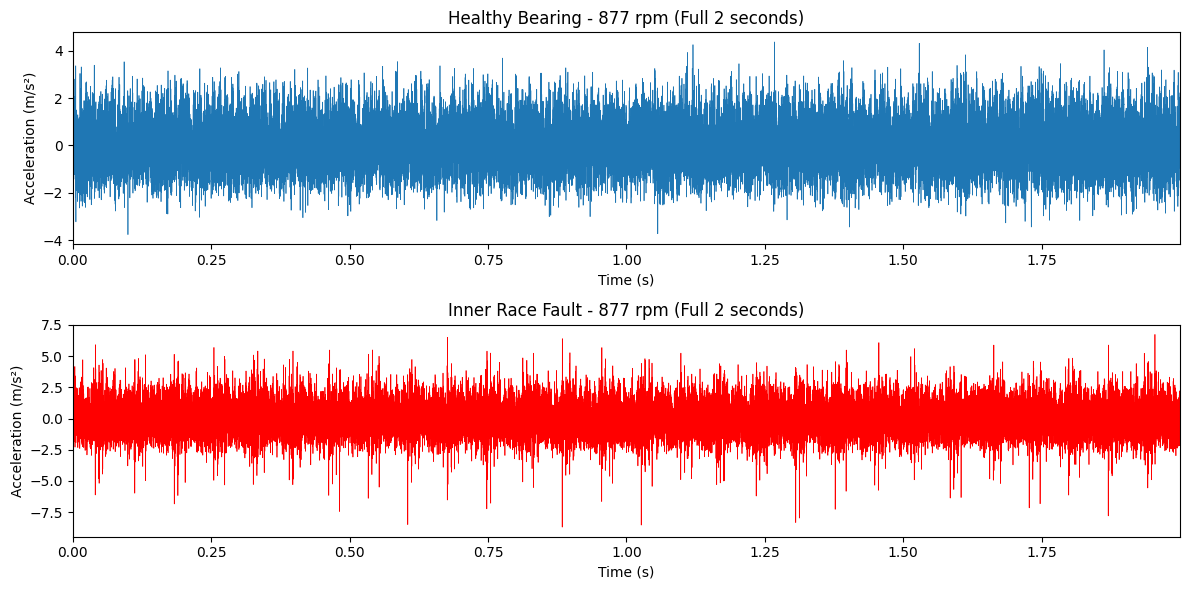

In [7]:
# Plot full 2-second signals
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Healthy
axes[0].plot(data_h['time_acc'], data_h['acc_m_s2'], linewidth=0.5)
axes[0].set_xlim(0, data_h['time_acc'][-1])  # Full duration
axes[0].set_title(f"Healthy Bearing - 877 rpm (Full 2 seconds)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Acceleration (m/s²)")

# Inner race fault
axes[1].plot(data_ir['time_acc'], data_ir['acc_m_s2'], linewidth=0.5, color='red')
axes[1].set_xlim(0, data_ir['time_acc'][-1])  # Full duration
axes[1].set_title(f"Inner Race Fault - 877 rpm (Full 2 seconds)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Acceleration (m/s²)")

plt.tight_layout()
plt.show()

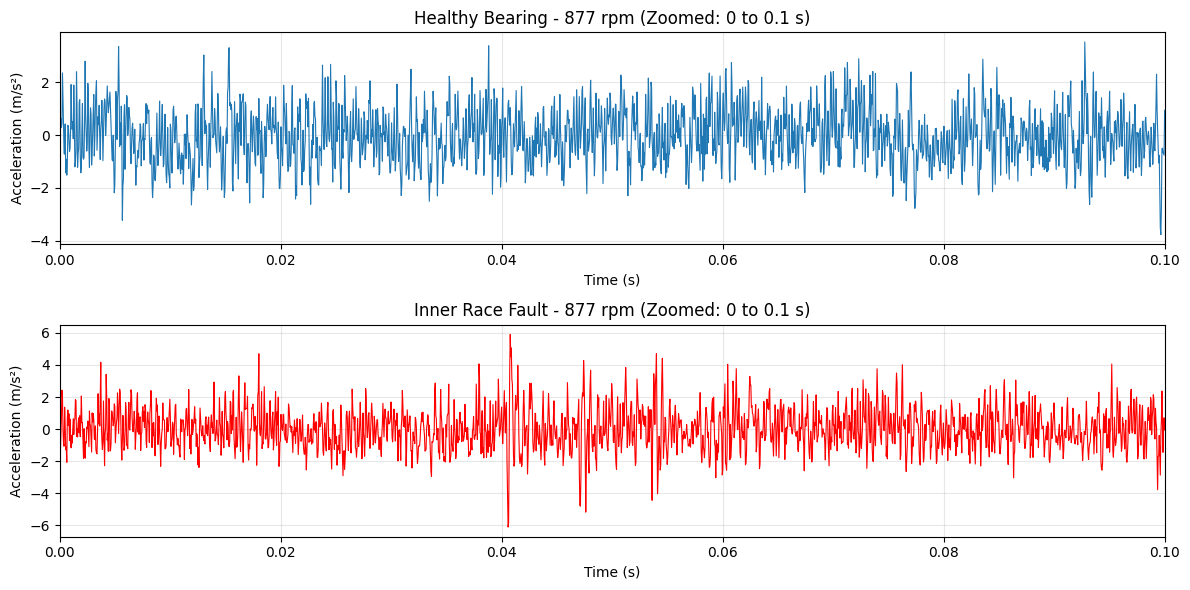

In [8]:
# Zoom into a short window (0.1 seconds) to see details
zoom_duration = 0.1  # seconds

# Find indices for zoom
idx_h = np.where(data_h['time_acc'] <= zoom_duration)[0]
idx_ir = np.where(data_ir['time_acc'] <= zoom_duration)[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Healthy (zoomed)
axes[0].plot(data_h['time_acc'][idx_h], data_h['acc_m_s2'][idx_h], linewidth=0.8)
axes[0].set_xlim(0, zoom_duration)
axes[0].set_title(f"Healthy Bearing - 877 rpm (Zoomed: 0 to {zoom_duration} s)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Acceleration (m/s²)")
axes[0].grid(True, alpha=0.3)

# Inner race fault (zoomed)
axes[1].plot(data_ir['time_acc'][idx_ir], data_ir['acc_m_s2'][idx_ir], linewidth=0.8, color='red')
axes[1].set_xlim(0, zoom_duration)
axes[1].set_title(f"Inner Race Fault - 877 rpm (Zoomed: 0 to {zoom_duration} s)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Acceleration (m/s²)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Time-Domain Features Comparison:
           Healthy  Inner Race Fault
RMS       0.995269          1.334172
Peak      4.370522          8.691693
Kurtosis  2.942898          4.261582


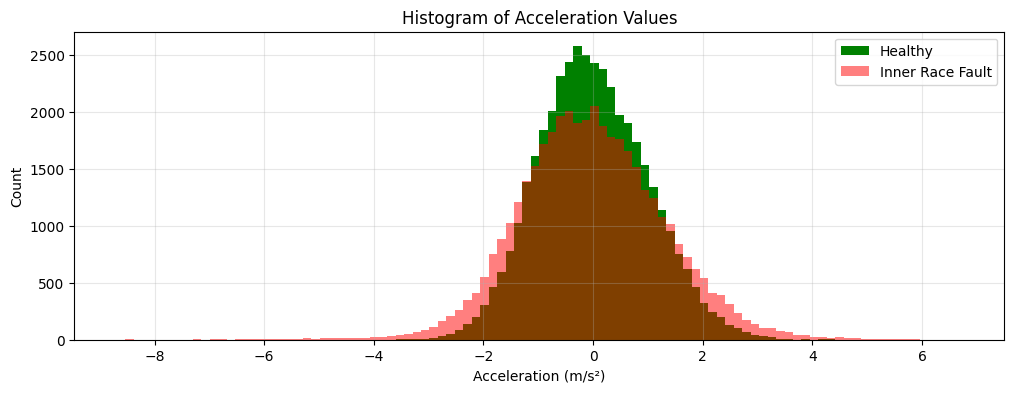

In [9]:
# Compute time-domain features
features_h = simple_time_features(data_h['acc_m_s2'])
features_ir = simple_time_features(data_ir['acc_m_s2'])

# Create comparison table
df_features = pd.DataFrame({
    'Healthy': features_h,
    'Inner Race Fault': features_ir
})

print("Time-Domain Features Comparison:")
print(df_features)


x_h  = data_h['acc_m_s2']
x_ir = data_ir['acc_m_s2']

bins = np.linspace(min(x_h.min(), x_ir.min()),
                   max(x_h.max(), x_ir.max()),
                   101)  # 100 bins -> 101 edges

plt.hist(x_h,  bins=bins, alpha=1.0, label='Healthy',         color='green')
plt.hist(x_ir, bins=bins, alpha=0.5, label='Inner Race Fault', color='red')

plt.title("Histogram of Acceleration Values")
plt.xlabel("Acceleration (m/s²)")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Observation**: The inner race fault **typically** shows **higher kurtosis** than the healthy bearing due to the presence of impulsive events when the rolling elements strike the damaged area. 
In the case of low rotational speeds, fault impacts might not be sufficiently strong to create much difference.

---

## 5. Bearing Geometry and Characteristic Fault Frequencies

### Understanding Bearing Kinematics

Before analyzing frequency spectra, it's crucial to understand **why** bearing faults create periodic vibrations at specific frequencies. This is not a random phenomenon and it's determined by the bearing's **geometry** and **kinematics**.

#### The Physics of Rolling Element Bearings

A rolling element bearing consists of:
- **Inner race** (rotates with the shaft)
- **Outer race** (typically stationary, mounted in the housing)
- **Rolling elements** (balls or rollers, held in a cage)
- **Cage** (keeps rolling elements evenly spaced)

<div style="background-color:#f0f8ff; padding:15px; border-left:4px solid #2196F3; margin:10px 0;">

**Key Insight:** When a fault (crack, spall, pit) exists on any of these components, it creates a **periodic impact** every time a rolling element passes over it. The frequency of these impacts depends on:

1. **Shaft rotational speed** (RPM)
2. **Number of rolling elements** (Z)
3. **Bearing geometry** (pitch diameter D, ball diameter d, contact angle α)

</div>

<div align="center">
<img src="images/BallBearing.gif" height="400"/>
<img src="images/Impact_bearing.jpg" height=400/>

**Figure:** Impact mechanism when a rolling element passes over a fault. Source: [Kim et al., 2020](https://www.mdpi.com/2076-3417/10/20/7302); [PlusMinus](https://en.wikipedia.org/wiki/Ball_bearing#/media/File:BallBearing.gif)
</div>

#### Characteristic Fault Frequencies

For the bearing used in this dataset, the fault frequencies (how many times per second does a fault hit a body) are calculated thorugh these formulae:

<div align="center">

| Quantity | Formula |
|---|---|
| Shaft rotational frequency | $f_s=\dfrac{RPM}{60}$ |
| FTF | $FTF=f_s\,\dfrac{1}{2}\left(1-\dfrac{d_{RE}}{d_p}\cos\alpha\right)$ |
| BPFO | $BPFO=f_s\,\dfrac{M}{2}\left(1-\dfrac{d_{RE}}{d_p}\cos\alpha\right)$ |
| BPFI | $BPFI=f_s\,\dfrac{M}{2}\left(1+\dfrac{d_{RE}}{d_p}\cos\alpha\right)$ |
| BSF | $BSF=f_s\,\dfrac{d_p}{d_{RE}}\left(1-\left(\dfrac{d_{RE}}{d_p}\cos\alpha\right)^2\right)$ |

<br>

With these geometries

<div align="center">

| Test Bearing Dimensions | Bearing Geometry Parameters |
|:------------------:|:---------------------------:|
| <img src="images/SKFCCKW33.png" width="400"/> | <img src="images/SKF_drawing.png" width="400"/> |

**Figure:** (Left) Fundamental dimensions of the SKF 22240 CC/W33 spherical roller bearing employed in our dataset. (Right) Bearing geometry. Source: [Giraudo et al., 2025](https://www.mdpi.com/1424-8220/25/8/2419)

</div>

If we calculate the non cinematic part of the formulas we get:

<div align="center">


| Fault Type | Frequency Calculation |
|-----------|---------------------|
| **BPFI** | $10.824 \times f_s$ |
| **BPFO** | $8.176 \times f_s$ |
| **2×BSF** | $2 \times 3.464 \times f_s$ | 
| **FTF** | $0.414 \times f_s$ | 

<br>




---




**So, now that we know that faulty bearing generate periodic impulses, we are capable of telling when a bearing is damaged, right?**

Well... not really.

How can you tell the difference between bearing fault and a gear fault? Or a jack hammer? Even, somebody hanghing a painting too close to your sensors?

</div>

<div align="center">

<img src="images/gears.jpg" height="300"/>
<img src="images/jackhammer.gif" height="300"/>
<img src="images/Hammering_Nails.jpg" height="300"/>

</div>


Two important tips:

- Frequency
- Shape

---

### Frequency

We already saw this before, let's calculate the fault frequencies at a certain speed.

**Important:** The nominal test speed is 353 RPM, but the actual measured mean speed (from the tachometer) is approximately **335–340 RPM** depending on the test condition. All analysis in this notebook uses the **measured mean RPM** for accurate frequency estimation.

Mean speed of **≈ 339 RPM** (healthy bearing at nominal 353 RPM):
- Shaft frequency: $f_s \approx 339/60 = 5.7$ Hz

| Fault Type | Frequency Calculation | **Frequency (Hz)** |
|-----------|---------------------|-------------------|
| **BPFI** | $10.824 \times 5.7$ | **≈ ? Hz** |
| **BPFO** | $8.176 \times 5.7$ | **≈ 46.6 Hz** |
| **2×BSF** | $2 \times 3.464 \times 5.7$ | **≈ ? Hz** |
| **FTF** | $0.414 \times 5.7$ | **≈ ? Hz** |

### Shape

**Let us try to recreate a faulty bearing signal.**

First we should discuss load zones.

Clearly, when loading a bearing, deflection occurs in all contacting components.

If we imagine a static outer ring and a loaded (and free to move) inner ring, we know that the rolling elements that are between the two rings are compressed, while the other ones are free of the contact forces generated by the load.

</div>

<div align="center">
<img src="images/deflection.png" height="400"/>

</div>

Without going too much into details, we can imagine to draw a line on the outer ring to represent the positions where the rolling elements would be loaded.

</div>

<div align="center">
<img src="images/loadzone.png" height="400"/>

**Figures:** Radial deflection and load zone of a simplified bearing. Source: [Harris](https://books.google.it/books?id=gdTLBQAAQBAJ&printsec=frontcover&hl=it&source=gbs_ge_summary_r&cad=0#v=onepage&q&f=false)
</div>



This slice of bearing is defined as **load zone** and depends on multiple factors (Bearing type and load, preload, materials).
In our case the load zone extends for half a circumference, **case (a)**.

___ 

Ok, now we can try to recreate a signal. Let's start with an Outer ring fault, that is located in the load zone

We know that an impact between rolling elements and faults generates impulses, so we create an **impulse train** to represent it


In [10]:
# Synthetic signal parameters
fs_synth = 25000  # Sampling frequency (Hz)
duration_synth = 10.0  # Duration (s)
t_synth = np.linspace(0, duration_synth, int(fs_synth * duration_synth), endpoint=False)

# High-frequency carrier
f_carrier = 75  # Hz our damage frequency
resp=signal.butter(10,f_carrier,fs=fs_synth/20,output='sos') #filter to represent a resonant response from the impulses impacting the bearing structure 
carrier = np.tile(signal.unit_impulse(int(1/f_carrier*fs_synth)), len(t_synth)//int(1/f_carrier*fs_synth))
carrier = signal.sosfilt(resp, carrier) #apply the filter to create a more realistic impulse response (resonance) rather than ideal impulses
carrier = carrier/np.max(carrier )  # Normalize to have consistent amplitude

# Low-frequency amplitude modulation to simulate the effect of the shaft rotation modulating the impulses
f_modulation = f_carrier/10.824  # Hz our spin speed
modulation =  np.sin(2 * np.pi * f_modulation * t_synth)
modulation = np.maximum(modulation, 0)  # Set negative values to zero to create a rectified modulation envelope

modulation = modulation[:len(carrier)]
t_synth = t_synth[:len(carrier)]  # Ensure modulation and carrier have the same length

# Modulated signal
signal_ir = modulation * carrier #ideal inner race fault signal (impulses modulated by the shaft rotation)
signal_or = carrier # ideal outer race fault signal 

# Add machine noise (e.g. electrical noise)
machine_noise = 0.01 * np.sin(2 * np.pi * 50 * t_synth) + 0.01* np.sin(2 * np.pi * 4000 * t_synth)  # 50 Hz and 4000 Hz electrical noise

# Add white noise
noise_level = 0.1
noise = noise_level * np.random.randn(len(signal_ir))
signal_ir_noisy = signal_ir + noise + machine_noise
signal_or_noisy = signal_or + noise + machine_noise


#calculate fft of the synthetic signal
freq_ir, amp_ir = compute_spectrum(signal_ir_noisy, fs_synth)
freq_or, amp_or = compute_spectrum(signal_or_noisy, fs_synth)

print(f"Simulated fault frequency for inner race fault: {f_carrier} Hz")
print(f"Simulated fault frequency for outer race fault: {f_carrier} Hz")
print(f"Simulated shaft frequency (1×RPM) for modulation: {f_modulation:.2f} Hz")

Simulated fault frequency for inner race fault: 75 Hz
Simulated fault frequency for outer race fault: 75 Hz
Simulated shaft frequency (1×RPM) for modulation: 6.93 Hz


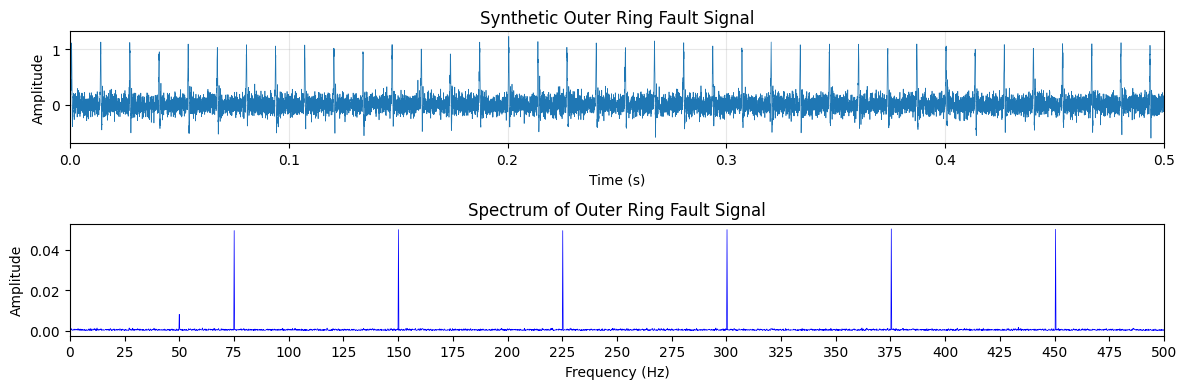

In [11]:
# Plot synthetic signal (short window)
plot_duration = 0.5  # seconds
idx_plot = np.where(t_synth <= plot_duration)[0]

fig, ax = plt.subplots(2, 1, figsize=(12, 4))

ax[0].plot(t_synth[idx_plot], signal_or_noisy[idx_plot], linewidth=0.5, label='Modulated signal + noise')
ax[0].set_xlim(0, plot_duration)
ax[0].set_title("Synthetic Outer Ring Fault Signal")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")
ax[0].grid(True, alpha=0.3)

ax[1].plot(freq_or, amp_or, linewidth=0.5, color='blue')
ax[1].set_title("Spectrum of Outer Ring Fault Signal")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Amplitude")
ax[1].set_xlim(0, 500)
ax[1].set_xticks(np.arange(0, 501, 25))

plt.tight_layout()
plt.show()

We can see clearly that the outer race faults generate single, periodic impulse responces each time a rolling element impacts the fault.

Now we can try to create an inner ring fault.

Since the fault rotates at the speed of the shaft  it would create impacts only when it is in the load zone, wich we can describe for our case as a half sine modulating wave.

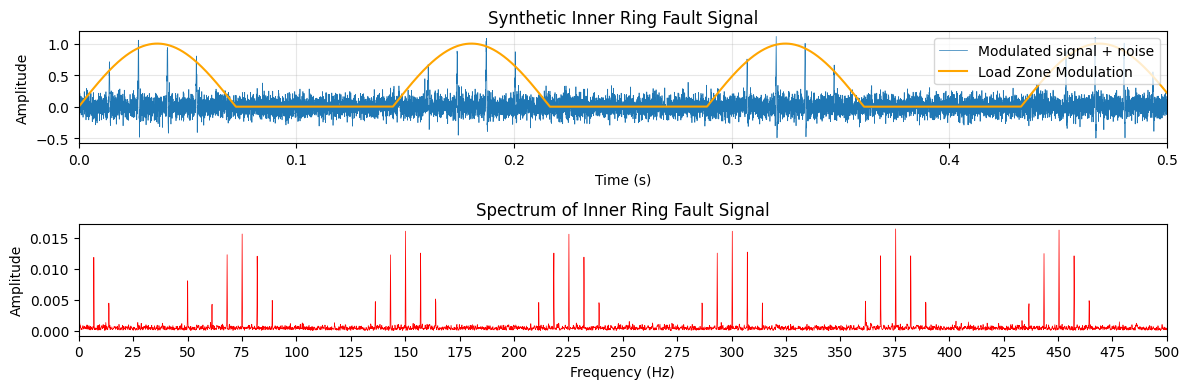

In [12]:
# Plot synthetic signal (short window)
plot_duration = 0.5  # seconds
idx_plot = np.where(t_synth <= plot_duration)[0]

fig, ax = plt.subplots(2, 1, figsize=(12, 4))

ax[0].plot(t_synth[idx_plot], signal_ir_noisy[idx_plot], linewidth=0.5, label='Modulated signal + noise')
ax[0].plot(t_synth[idx_plot], modulation[idx_plot], linewidth=1.5, label='Load Zone Modulation', color='orange')
ax[0].legend(loc='upper right')
ax[0].set_xlim(0, plot_duration)
ax[0].set_title("Synthetic Inner Ring Fault Signal")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")
ax[0].grid(True, alpha=0.3)

ax[1].plot(freq_ir, amp_ir, linewidth=0.5, color='red')
ax[1].set_title("Spectrum of Inner Ring Fault Signal")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Amplitude")
ax[1].set_xlim(0, 500) 
ax[1].set_xticks(np.arange(0, 501, 25))

plt.tight_layout()
plt.show()

# Let's Focus on the Shape of the FFT
Why does it look like this?

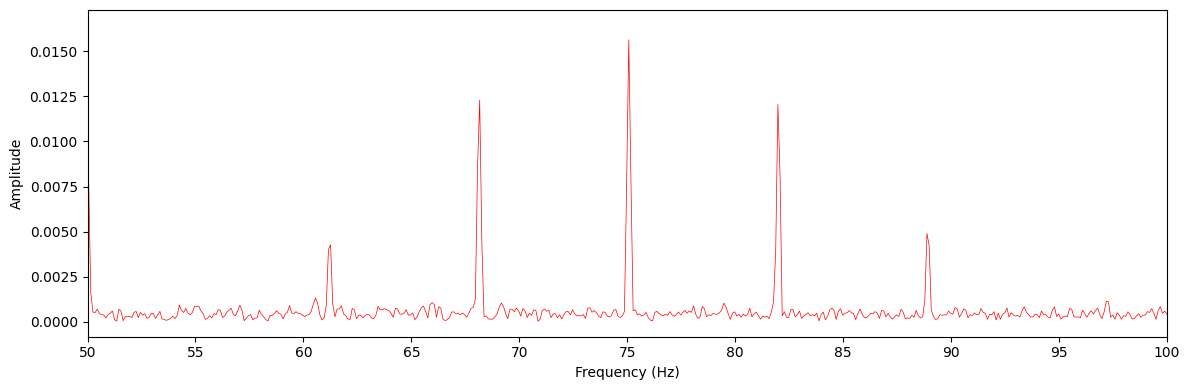

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(freq_ir, amp_ir, linewidth=0.5, color='red')
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude")
ax.set_xlim(50, 100) 
ax.set_xticks(np.arange(50, 101, 5))

plt.tight_layout()
plt.show()

Try to center it and find the main frequencies

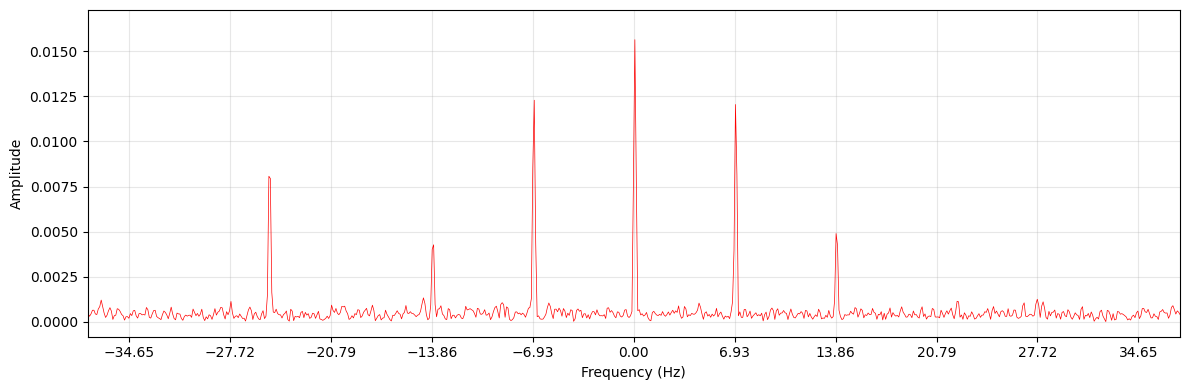

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))



ax.plot(freq_ir-f_carrier, amp_ir, linewidth=0.5, color='red')
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude")
ax.set_xlim(-f_carrier/2, f_carrier/2) 
ax.grid(True, alpha=0.3)
ax.set_xticks(np.arange(-5*f_modulation, 5*f_modulation + 1, f_modulation)) #create ticks at modulation frequency intervals to center at the sidebands

plt.tight_layout()
plt.show()

The distance between the peaks in the envelope spectrum corresponds exactly to the modulation frequency.

Basically, we have a product of two periodic signals (fault impacts and load zone modulation) that we are trying to describe in the frequency domain through the Fourier Transform, which is based on a summation of sines and cosines...

</div>

<div align="center">
<img src="images/serief.svg" height="70"/>


</div>

The most elegant explanation I could find was on [Wikipedia](https://en.wikipedia.org/wiki/Sideband#Sideband_creation):

</div>

<div align="center">
<img src="images/sideband.png" height="300"/>


</div>





So since the inner ring faulted signals are **modulated periodical peaks**, we can always expect the frequency spectrum to have carriers at the **BPFI** and sidebands at **BPFI $\pm n f_{ir}$**.

<div align="center">

 <img src="images/sideband2.png" width="400"/> 


**Figure:** Typical bearing local faults signals diagram. Source: [Igor Dotsenko](https://quantum-technologies.iap.uni-bonn.de/assets/pdf/thesis/master/dipldotigo.pdf)

</div>

---

#### **To recap**

<div align="center">

 <img src="images/danni.jpg" width="400"/> 


**Figure:** Typical bearing local faults signals diagram. Source: [Lu et al.](https://doi.org/10.1080/23307706.2025.2526054)

</div>

**Now that we know wath we are looking for we can try to identify the damage on real signals.**

---

# 6 A little reharse on envelope analisys and filtering

## Why?
Faults generate high frequency responces from the structure of the bearing and the machine. These high frequencies are useless to diagnose faults but have a big presence in the spectrum of a signal, shadowing fault frequencies.
Envelopes 

## How?

Filtering and envelope analysis
# Filtering
There are multiple bandpass filters out there. The gist of it is that we reduce the magnitude of low (modulating) and high (structural) frequencies.
# The Hilbert Transform and the analitical signal

### $\mathcal{H}\{x(t)\}=\hat{x}(t)=\frac{1}{\pi}\,\int_{-\infty}^{\infty}\frac{x(\tau)}{t-\tau}\,d\tau = x(t)*\frac{1}{\pi t}$

A very good explanation of the Hilbert transform is this [one](https://www.comm.utoronto.ca/~frank/notes/hilbert.pdf)

What it does is shift the phase of all components of a signal $x(t)$ of $-\frac{\pi}{2}$ for all positive frequencies and $+\frac{\pi}{2}$ for the negative ones, like this:

$X(\omega)\cdot
\begin{cases}
-j, & \omega>0\\
0, & \omega=0\\
+j, & \omega<0
\end{cases}$

then we sum the original to this trasformed signal times i, to create the analytical signal

$x_{an}=x(t)+i\hat{x}(t)= \mathcal{F}^{-1}(X(\omega)) +
i\mathcal{F}^{-1}\left(X(\omega)
\begin{cases}
-j, & \omega>0\\
0, & \omega=0\\
+j, & \omega<0
\end{cases}\right) = \mathcal{F}^{-1}\left(X(\omega)
\begin{cases}
2, & \omega>0\\
1, & \omega=0\\
0, & \omega<0
\end{cases}\right) $

Creating a signal that has **zero valued negative frequencies**

like this:

We have our signal


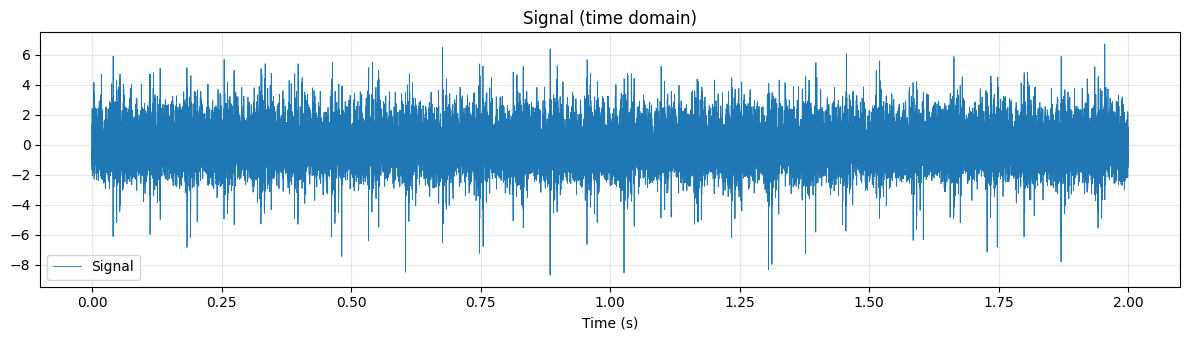

In [15]:
x = np.fft.fft(data_ir['acc_m_s2'])  # FFT of the signal
f = np.fft.fftshift(np.fft.fftfreq(len(data_ir['acc_m_s2']), d=1/data_ir['fs_acc']))  # Generate frequency axis (shifted for plotting)
x = np.fft.fftshift(x)  # Shift FFT to match f ordering (negative -> positive)

phase = np.angle(x)  # Phase spectrum

step_fcn = np.zeros(len(f))  # Initialize step function (Hilbert / analytic signal filter)
step_fcn[f > 0] = 2  # Positive frequencies -> multiply by 2
step_fcn[f == 0] = 1  # DC component -> keep as 1
step_fcn[f < 0] = 0  # Negative frequencies -> zero out

fft_an = x * step_fcn  # Apply step function in frequency domain (analytic signal spectrum)

hilb_ir = np.fft.ifft(np.fft.ifftshift(fft_an))  # Back to time domain (undo shift, then IFFT)
hilb_phase = np.angle(hilb_ir)  # Phase of the analytic signal

env_fft = np.fft.fft(np.abs(hilb_ir))  # FFT of the envelope (UNSHIFTED)
env_fft = np.fft.fftshift(env_fft)  # Shift envelope FFT to match f ordering (SHIFTED like f)
env_phase = np.angle(env_fft)  # Phase of the envelope spectrum

print("We have our signal")  # Print right before plot
plt.figure(figsize=(12, 3.5))
plt.plot(data_ir['time_acc'], data_ir['acc_m_s2'], linewidth=0.6, label='Signal')  # Plot signal in time domain
plt.xlabel("Time (s)")  # X label
plt.title("Signal (time domain)")  # Title
plt.grid(True, alpha=0.3)  # Grid
plt.legend()  # Legend
plt.tight_layout()  # Better spacing


and its spectrum, with Phase


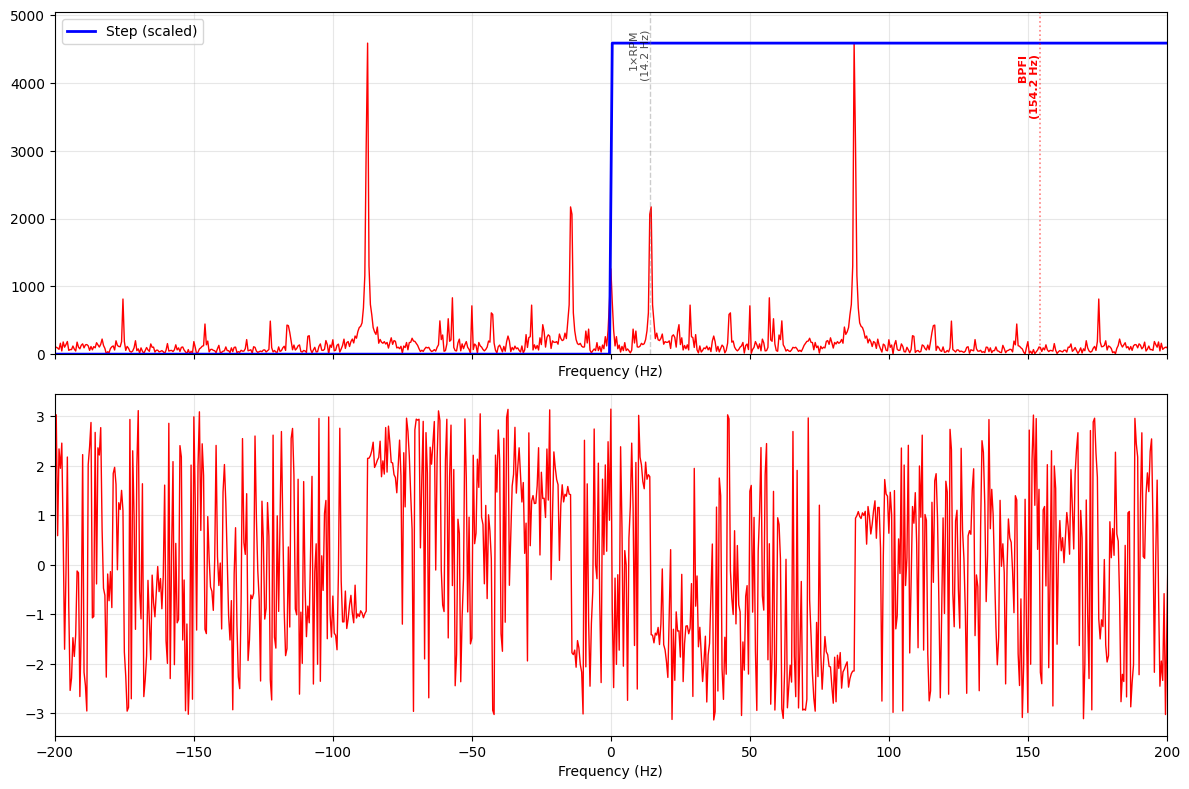

In [16]:

print("and its spectrum, with Phase")  # Print right before plot
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Fix y-limits: use a boolean mask (your env_fft[f==10:f==200] was not valid)
mask_env = (f >= 10) & (f <= 200)  # Take y max in 10..200 Hz only (avoid DC spike)
ax[0].plot(f, np.abs(x), linewidth=1, color='red')  # Magnitude spectrum
ax[0].plot(f, step_fcn/2* np.max(np.abs(x[mask_env])), label='Step (scaled)', color='blue', linewidth=2)  # Step function overlay (scaled)
ax[0].set_xlim(-200, 200)  # Frequency limits
ax[0].set_ylim(0, np.max(np.abs(x[mask_env])) * 1.1)  # Y limits to focus on the spectrum
add_rpm_harmonics(ax[0], data_ir['mean_rpm'], max_freq=200, alpha=0.2)
add_bearing_fault_frequencies(ax[0], data_ir['mean_rpm'], 'IR', max_freq=200)
ax[0].set_xlabel("Frequency (Hz)")  # X label
ax[0].grid(True, alpha=0.3)  # Grid
ax[0].legend()  # Legend
ax[1].plot(f, phase, linewidth=1, color='red')  # Phase spectrum
ax[1].set_xlim(-200, 200)  # Frequency limits
ax[1].set_xlabel("Frequency (Hz)")  # X label
ax[1].grid(True, alpha=0.3)  # Grid

plt.tight_layout()
plt.show()

Now we multiply by the step function to get the analytic signal spectrum


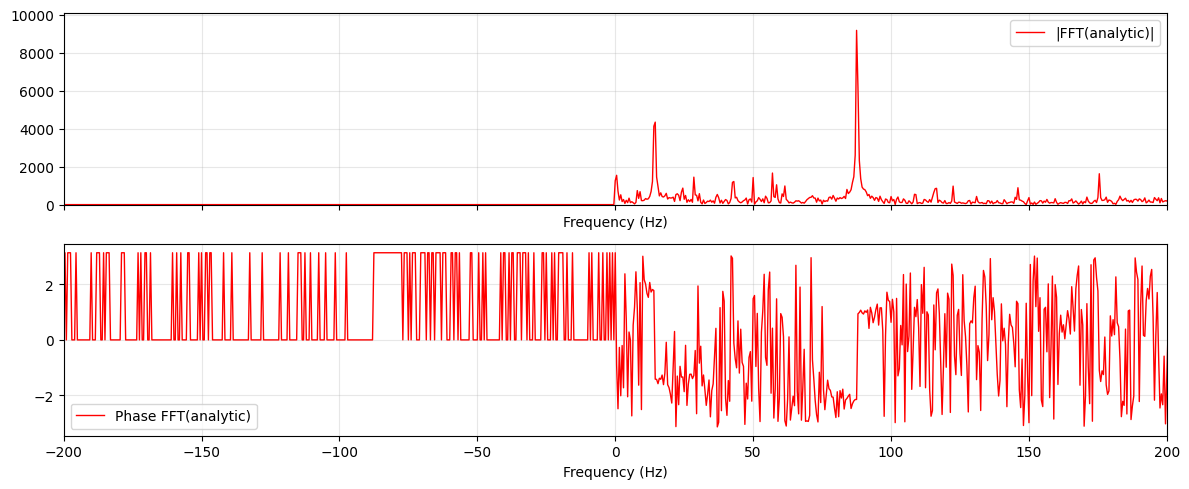

In [17]:

print("Now we multiply by the step function to get the analytic signal spectrum")  # Print right before plot
fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax[0].plot(f, np.abs(fft_an), label='|FFT(analytic)|', color='red', linewidth=1)  # Analytic spectrum magnitude
ax[0].set_xlim(-200, 200)  # Frequency limits
ax[0].set_ylim(0, np.max(np.abs(fft_an[mask_env])) * 1.1)  # Y limits to focus on envelope spectrum
ax[0].set_xlabel("Frequency (Hz)")  # X label
ax[0].grid(True, alpha=0.3)  # Grid
ax[0].legend()  # Legend
ax[1].plot(f, np.angle(fft_an), label='Phase FFT(analytic)', color='red', linewidth=1)  # Analytic spectrum phase
ax[1].set_xlim(-200, 200)  # Frequency limits
ax[1].set_xlabel("Frequency (Hz)")  # X label
ax[1].grid(True, alpha=0.3)  # Grid
ax[1].legend()  # Legend
fig.tight_layout()  # Better spacing


Finally, we use the IFFT to get the analytic signal in time domain, calculate its absolute value to get the envelope


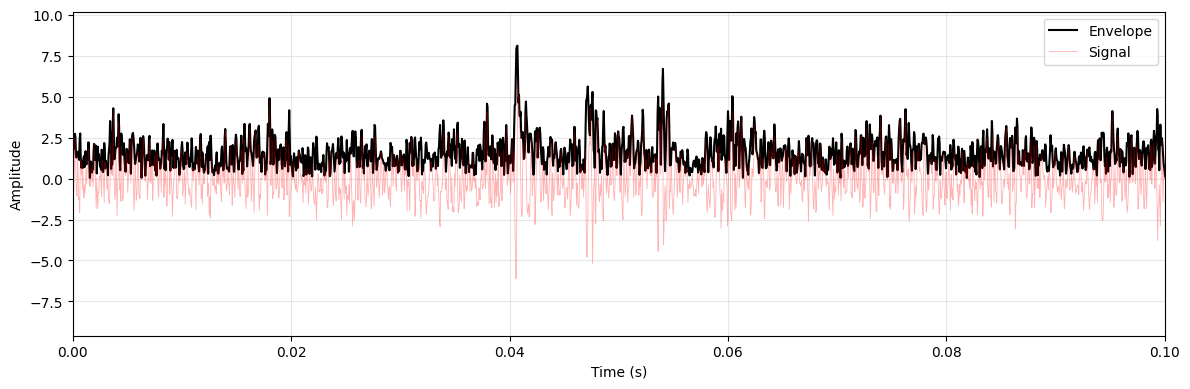

In [18]:

print("Finally, we use the IFFT to get the analytic signal in time domain, calculate its absolute value to get the envelope")  # Print right before plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(data_ir['time_acc'], np.abs(hilb_ir), label='Envelope', color='black', linewidth=1.5)  # Envelope = magnitude of analytic signal
ax.plot(data_ir['time_acc'], data_ir['acc_m_s2'], label='Signal', color='red', alpha=0.3, linewidth=0.6)  # Original signal (transparent)
ax.set_xlim(0.0, 0.1)  # Zoom in time
ax.set_xlabel("Time (s)")  # X label
ax.set_ylabel("Amplitude")  # Y label
ax.grid(True, alpha=0.3)  # Grid
ax.legend()  # Legend
fig.tight_layout()  # Better spacing


Now we plot the envelope spectrum and the analytic-signal phase spectrum


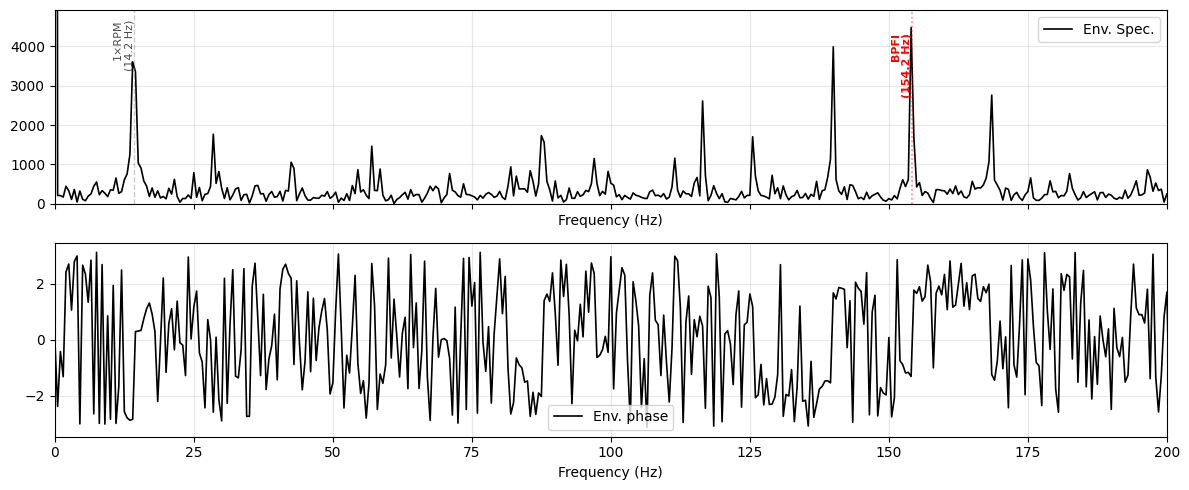

In [19]:

print("Now we plot the envelope spectrum and the analytic-signal phase spectrum")  

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

ax[0].plot(f, np.abs(env_fft), label='Env. Spec.', linewidth=1.2, color='black')  # Envelope spectrum (magnitude)
ax[0].set_xlim(0, 200)  # Frequency limits

# Fix y-limits: use a boolean mask (your env_fft[f==10:f==200] was not valid)
mask_env = (f >= 10) & (f <= 200)  # Take y max in 10..200 Hz only (avoid DC spike)
ax[0].set_ylim(0, np.max(np.abs(env_fft[mask_env])) * 1.1)  # Y limits to focus on envelope spectrum
add_rpm_harmonics(ax[0], data_ir['mean_rpm'], max_freq=200, alpha=0.2)
add_bearing_fault_frequencies(ax[0], data_ir['mean_rpm'], 'IR', max_freq=200)
ax[0].set_xlabel("Frequency (Hz)")  # X label
ax[0].grid(True, alpha=0.3)  # Grid
ax[0].legend()  # Legend

# Fix last plot: env_phase is already angle(env_fft), so don't do angle(angle(...))
ax[1].plot(f, env_phase, label='Env. phase', linewidth=1.2,color='black')  # Envelope spectrum phase
ax[1].set_xlim(0, 200)  # Frequency limits
ax[1].set_xlabel("Frequency (Hz)")  # X label
ax[1].grid(True, alpha=0.3)  # Grid
ax[1].legend()  # Legend

fig.tight_layout()  # Better spacing
plt.show()  # Show plot

## 7 Now we can apply what we learned to real signals


In [20]:
# Load data at 877 rpm
data_h_877 = load_sample('H_877rpm_sample.mat')
data_ir_877 = load_sample('IR_877rpm_sample.mat')


In [21]:
#Filter range

bandpass_range = (1000, 3000)  

print(f"Band-pass filter range: {bandpass_range[0]} Hz to {bandpass_range[1]} Hz")
print()


Band-pass filter range: 1000 Hz to 3000 Hz



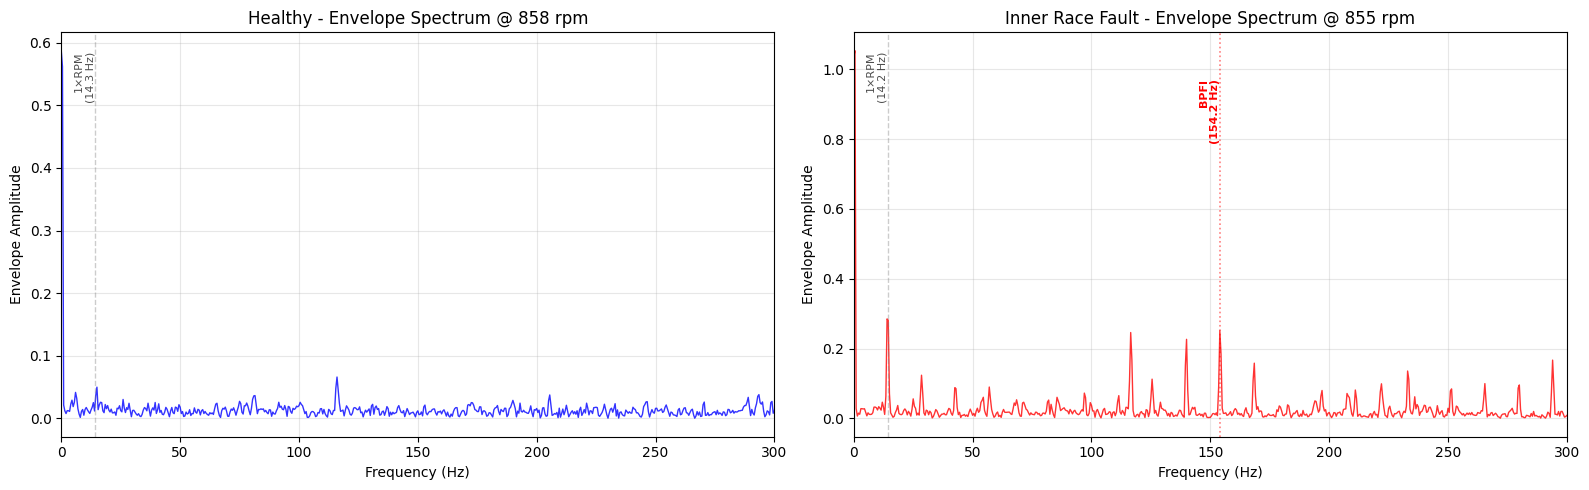

In [22]:
# Compute envelope spectra for Healthy and Inner Race at 877 rpm
freq_env_h_877, env_spec_h_877, _, _ = envelope_spectrum(
    data_h_877['acc_m_s2'], data_h_877['fs_acc'], bandpass=bandpass_range
)
freq_env_ir_877, env_spec_ir_877, _, _ = envelope_spectrum(
    data_ir_877['acc_m_s2'], data_ir_877['fs_acc'], bandpass=bandpass_range
)

# Plot envelope spectra side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Healthy
axes[0].plot(freq_env_h_877, env_spec_h_877, linewidth=1.0, color='blue', alpha=0.8)
axes[0].set_title(f"Healthy - Envelope Spectrum @ {data_h_877['mean_rpm']:.0f} rpm")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Envelope Amplitude")
axes[0].set_xlim([0, 300])
add_rpm_harmonics(axes[0], data_h_877['mean_rpm'], max_freq=300, alpha=0.2)
axes[0].grid(True, alpha=0.3)

# Inner Race Fault
axes[1].plot(freq_env_ir_877, env_spec_ir_877, linewidth=1.0, color='red', alpha=0.8)
axes[1].set_title(f"Inner Race Fault - Envelope Spectrum @ {data_ir_877['mean_rpm']:.0f} rpm")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Envelope Amplitude")
axes[1].set_xlim([0, 300])
add_rpm_harmonics(axes[1], data_ir_877['mean_rpm'], max_freq=300, alpha=0.2)
add_bearing_fault_frequencies(axes[1], data_ir_877['mean_rpm'], 'IR', max_freq=300, alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###  Outer Race Fault

**Expected Fault Frequency:** BPFO = 8.176 × (858.9/60) ≈ **117.1 Hz** (using measured mean RPM)


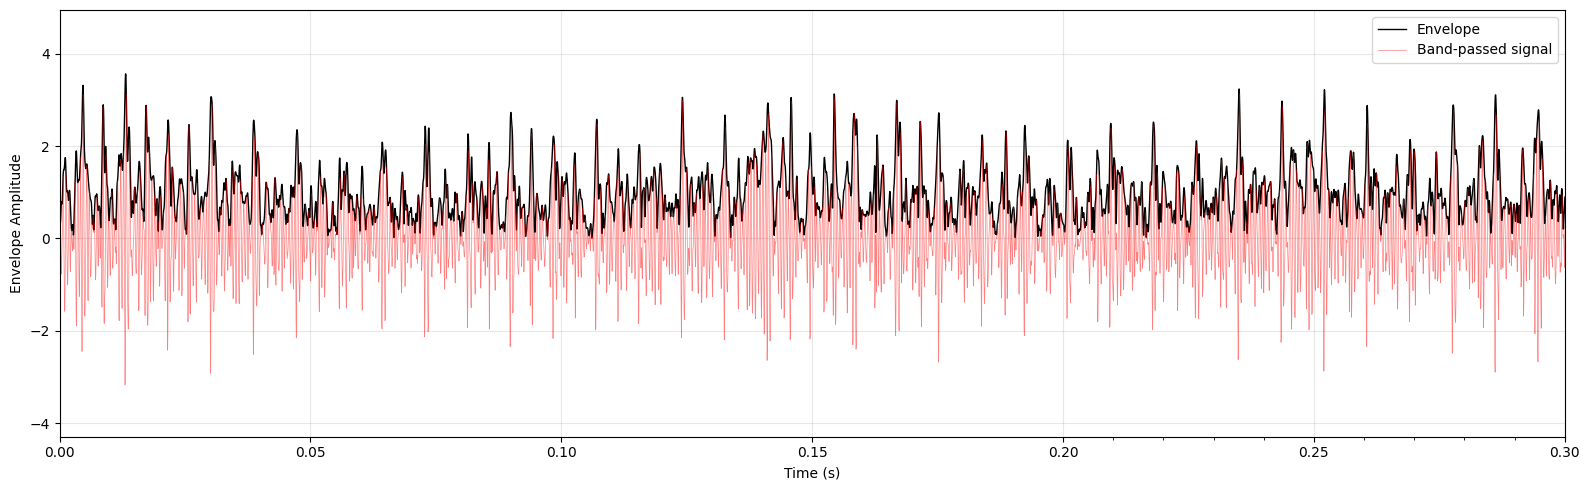

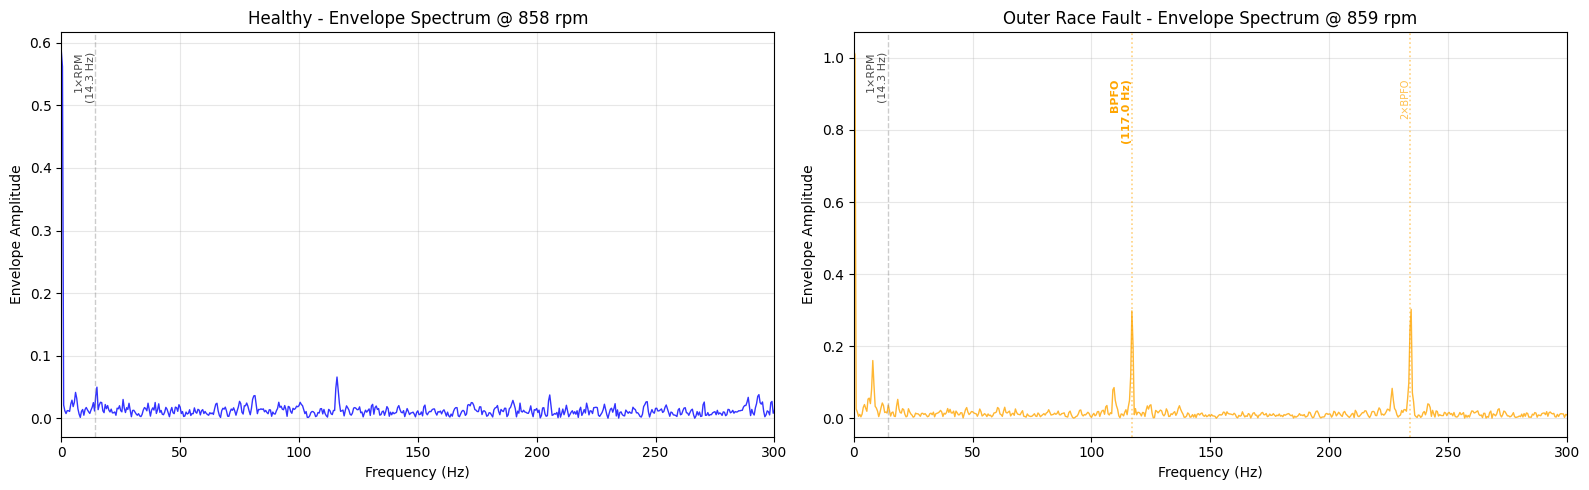

In [23]:
# Load Outer Race fault data at 877 rpm
data_or_877 = load_sample('OR_877rpm_sample.mat')

# Compute FFT spectra
freq_or_877, amp_or_877 = compute_spectrum(data_or_877['acc_m_s2'], data_or_877['fs_acc'])

# Compute envelope spectra for Outer Race at 877 rpm
freq_env_or_877, env_spec_or_877, env_or_877, filt_or_877 = envelope_spectrum(
    data_or_877['acc_m_s2'], data_or_877['fs_acc'], bandpass=bandpass_range
)

# Plot envelope spectra side-by-side
fig, axes = plt.subplots( figsize=(16, 5))
axes.plot(data_or_877['time_acc'], env_or_877, linewidth=1.0, color='black', alpha=1.0, label='Envelope')
axes.plot(data_or_877['time_acc'], filt_or_877, linewidth=0.5, color='red', alpha=0.5, label='Band-passed signal')
axes.set_xlim(0, 0.3)
axes.set_xlabel("Time (s)")
axes.set_ylabel("Envelope Amplitude")
axes.grid(True, alpha=0.3)
axes.set_xticks(np.arange(0.2, 0.31, 0.01), minor=True)
axes.legend()


plt.tight_layout()
plt.show()

# Plot envelope spectra side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Healthy
axes[0].plot(freq_env_h_877, env_spec_h_877, linewidth=1.0, color='blue', alpha=0.8)
axes[0].set_title(f"Healthy - Envelope Spectrum @ {data_h_877['mean_rpm']:.0f} rpm")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Envelope Amplitude")
axes[0].set_xlim([0, 300])
add_rpm_harmonics(axes[0], data_h_877['mean_rpm'], max_freq=300, alpha=0.2)
axes[0].grid(True, alpha=0.3)

# Outer Race Fault
axes[1].plot(freq_env_or_877, env_spec_or_877, linewidth=1.0, color='orange', alpha=0.8)
axes[1].set_title(f"Outer Race Fault - Envelope Spectrum @ {data_or_877['mean_rpm']:.0f} rpm")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Envelope Amplitude")
axes[1].set_xlim([0, 300])
add_rpm_harmonics(axes[1], data_or_877['mean_rpm'], max_freq=300, alpha=0.2)
add_bearing_fault_frequencies(axes[1], data_or_877['mean_rpm'], 'OR', max_freq=300, alpha=0.5, color='orange')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 8 Comparative Analysis at 353 rpm: Healthy vs Outer Race Faults


**Why 353 rpm?**
- Weaker impact forces → smaller fault signatures
- Signal is often lower in magnitude than noise
- Better signal preprocessing is fundamental

In [24]:
# Load data at 353 rpm
data_h_353 = load_sample('H_353rpm_sample.mat')
data_or_353 = load_sample('OR_353rpm_sample.mat')


###  Outer Race Fault

**Expected Fault Frequency:** BPFO = 8.176 × (340/60) ≈ **46.3 Hz** (using measured mean RPM)

In [25]:
# Compute  env spectra


# Plot envelope spectra side-by-side




#### Envelope Analysis

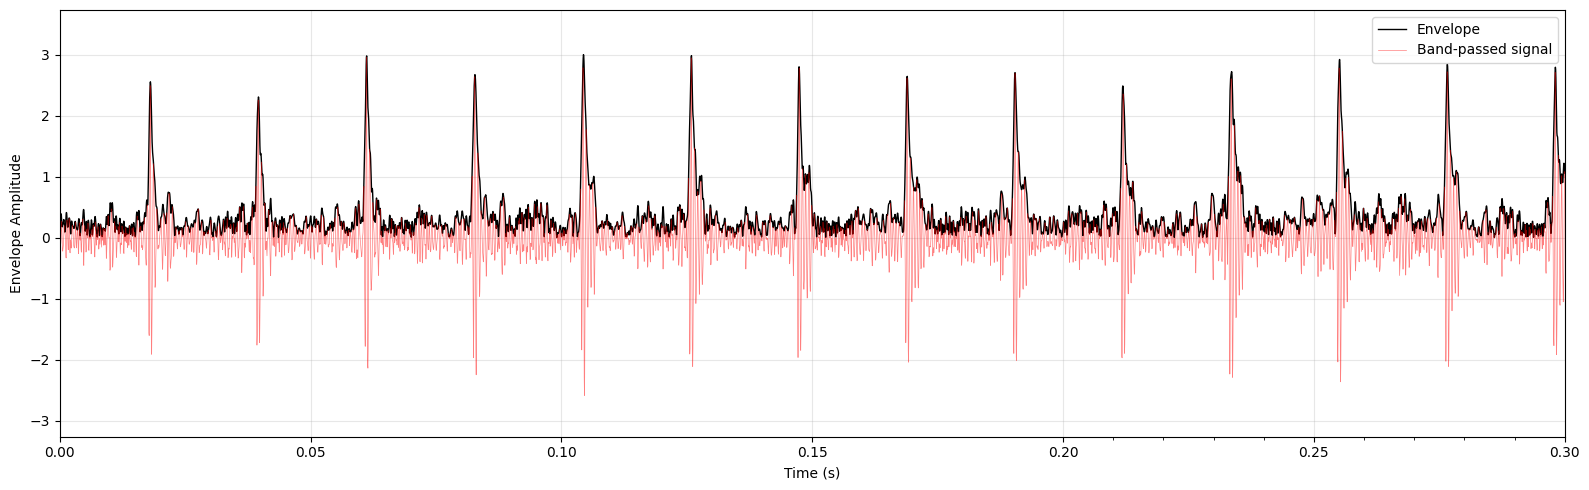

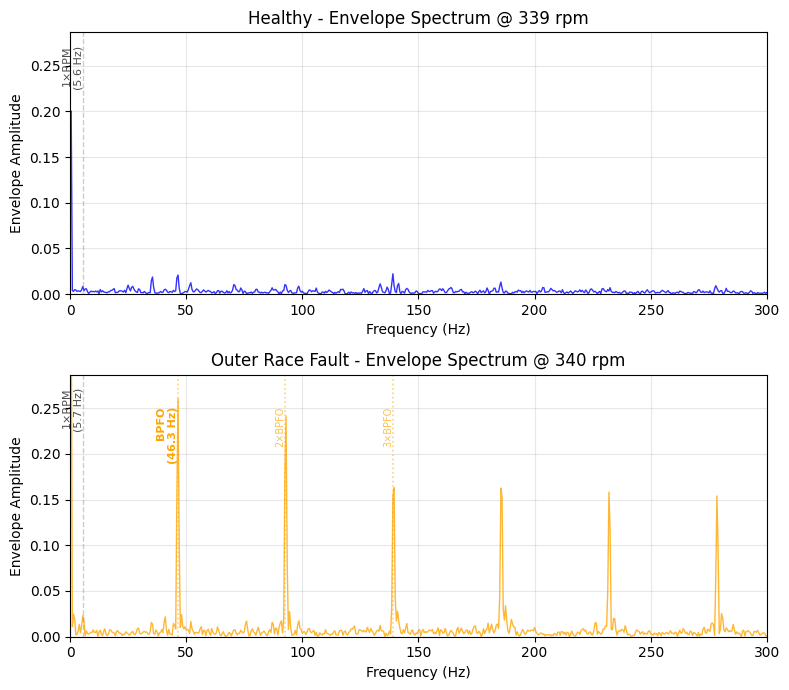

In [26]:
# Compute envelope spectra at 353 rpm
freq_env_or_353, env_spec_or_353 , env_or_353, filt_or_353 = envelope_spectrum(data_or_353['acc_m_s2'], data_or_353['fs_acc'], bandpass=bandpass_range)
freq_env_h_353, env_spec_h_353 , env_h_353, filt_h_353 = envelope_spectrum(data_h_353['acc_m_s2'], data_h_353['fs_acc'], bandpass=bandpass_range)

# Plot envelope and filtered signal in time domain for Outer Race fault at 353 rpm
fig, axes = plt.subplots( figsize=(16, 5))
axes.plot(data_or_353['time_acc'], env_or_353, linewidth=1.0, color='black', alpha=1.0, label='Envelope')
axes.plot(data_or_353['time_acc'], filt_or_353, linewidth=0.5, color='red', alpha=0.5, label='Band-passed signal')
axes.set_xlim(0, 0.3)
axes.set_xlabel("Time (s)")
axes.set_ylabel("Envelope Amplitude")
axes.grid(True, alpha=0.3)
axes.set_xticks(np.arange(0.2, 0.31, 0.01), minor=True)
axes.legend()


plt.tight_layout()
plt.show()

# Plot envelope spectra side-by-side
fig, axes = plt.subplots(2, 1, figsize=(8, 7))

# Healthy
axes[0].plot(freq_env_h_353, env_spec_h_353, linewidth=1.0, color='blue', alpha=0.8)
axes[0].set_title(f"Healthy - Envelope Spectrum @ {data_h_353['mean_rpm']:.0f} rpm")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Envelope Amplitude")
axes[0].set_xlim([0, 300])
axes[0].set_ylim(0, np.max(env_spec_or_353[int(5/np.max(freq_env_or_353)*len(freq_env_or_353)):int(300/np.max(freq_env_or_353)*len(freq_env_or_353))]*1.1))
add_rpm_harmonics(axes[0], data_h_353['mean_rpm'], max_freq=300, alpha=0.2)
axes[0].grid(True, alpha=0.3)

# Outer Race Fault
axes[1].plot(freq_env_or_353, env_spec_or_353, linewidth=1.0, color='orange', alpha=0.8)
axes[1].set_title(f"Outer Race Fault - Envelope Spectrum @ {data_or_353['mean_rpm']:.0f} rpm")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Envelope Amplitude")
axes[1].set_xlim([0, 300])
axes[1].set_ylim(0, np.max(env_spec_or_353[int(5/np.max(freq_env_or_353)*len(freq_env_or_353)):int(300/np.max(freq_env_or_353)*len(freq_env_or_353))]*1.1))
add_rpm_harmonics(axes[1], data_or_353['mean_rpm'], max_freq=300, alpha=0.2)
add_bearing_fault_frequencies(axes[1], data_or_353['mean_rpm'], 'OR', max_freq=300, alpha=0.5, color='orange')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 9 Your Assignement

Take on Rolling element faults and answer the questions in this survey:

https://docs.google.com/forms/d/e/1FAIpQLSdm0lbV7CrT25q4O1QlDsxz6ZW5RHliFgjFBIHvfEutA-GbeQ/viewform?usp=publish-editor



In [27]:
#Filter range

bandpass_range = (1000, 3000)  

print(f"Band-pass filter range: {bandpass_range[0]} Hz to {bandpass_range[1]} Hz")
print()


Band-pass filter range: 1000 Hz to 3000 Hz



In [28]:
# You can write code or copy-paste code here to create the plots needed for your assignment
# use the functions defined above to help with plotting and analysis
# make your graphs clear and understandable, with titles, axis labels, legends, and grid as needed